In [6]:
import numpy as np

# 1. 构建例题中的5x5原始图像矩阵
original_image = np.array([
    [10, 20, 30, 40, 50],
    [15, 25, 35, 45, 55],
    [20, 30, 40, 50, 60],
    [25, 35, 45, 55, 65],
    [30, 40, 50, 60, 70]
], dtype=np.uint8)

# 2. 提取3x3邻域窗口（对应中心像素(2,2)，行1-3，列1-3）
neighborhood = original_image[1:4, 1:4]  # 切片：左闭右开，1:4对应索引1、2、3

# 3. 计算邻域窗口的总和与平均值（模拟均值滤波核心计算）
neighborhood_sum = np.sum(neighborhood)
neighborhood_mean = np.mean(neighborhood)

# 4. 打印结果，验证手动计算
print("=== 均值滤波例题验证结果 ===")
print(f"3x3邻域窗口像素矩阵：\n{neighborhood}")
print(f"邻域窗口像素总和：{neighborhood_sum}")
print(f"邻域窗口像素平均值（滤波后结果）：{neighborhood_mean}")

=== 均值滤波例题验证结果 ===
3x3邻域窗口像素矩阵：
[[25 35 45]
 [30 40 50]
 [35 45 55]]
邻域窗口像素总和：360
邻域窗口像素平均值（滤波后结果）：40.0


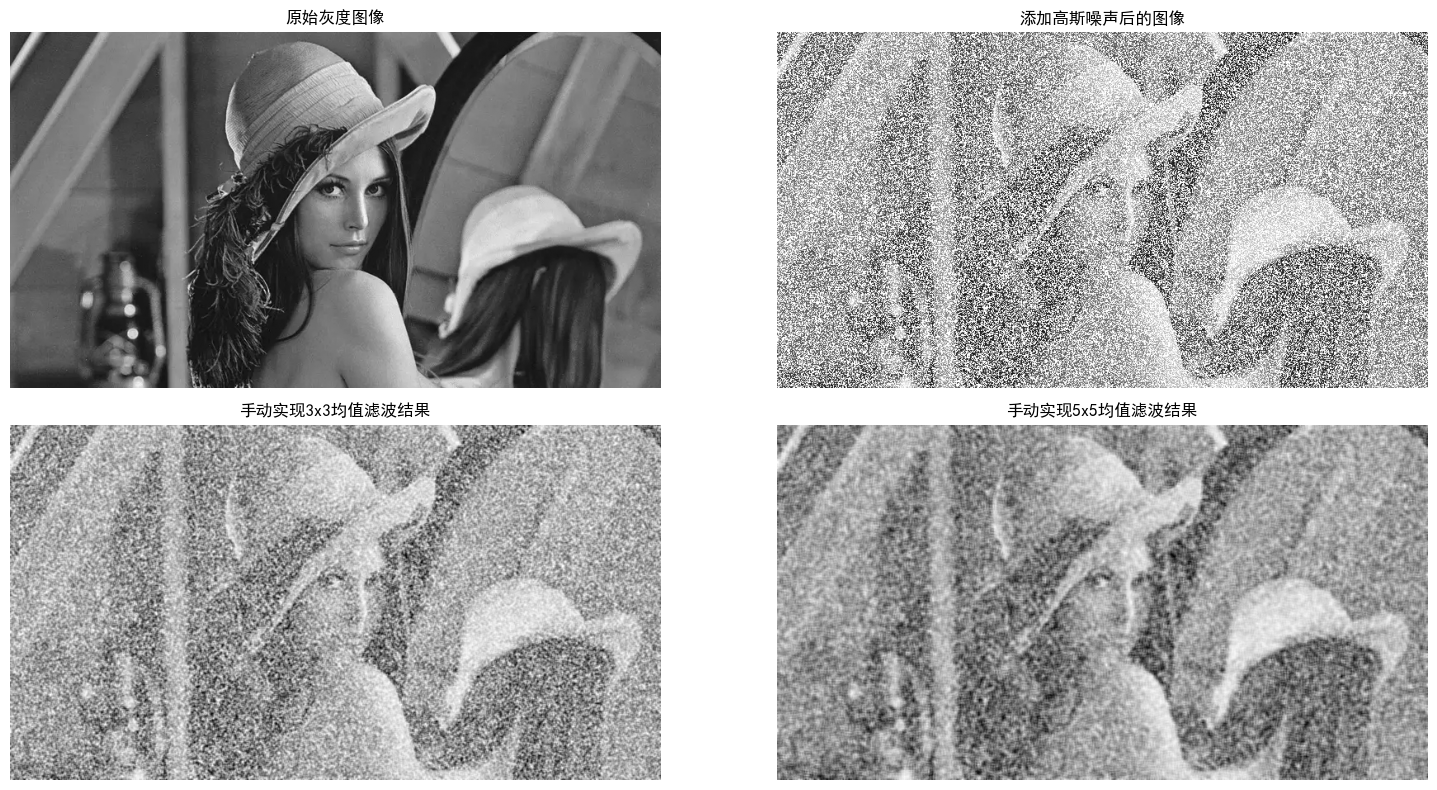

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -------- 核心：添加Matplotlib中文显示配置 --------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def manual_mean_filter(image, kernel_size=3):
    """
    手动实现均值滤波（支持灰度图像）
    :param image: 输入灰度图像（numpy数组）
    :param kernel_size: 卷积核尺寸（奇数，默认3）
    :return: 均值滤波后的输出图像
    """
    if kernel_size % 2 == 0:
        raise ValueError("卷积核尺寸必须为奇数，请修改kernel_size参数")

    h, w = image.shape
    pad_size = kernel_size // 2
    padded_image = np.pad(image, pad_width=pad_size, mode='edge')
    output_image = np.zeros_like(image)

    for y in range(h):
        for x in range(w):
            neighborhood = padded_image[y:y+kernel_size, x:x+kernel_size]
            output_image[y, x] = np.mean(neighborhood)

    return output_image.astype(np.uint8)

# ---------------------- 测试手动实现的均值滤波 ----------------------
# 读取img目录下的图像（路径保持不变）
img_gray = cv2.imread("../img/lena.jpeg", cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError("未找到测试图像，请确保img/test_image.jpg在对应目录下")

# 添加高斯噪声
np.random.seed(42)
noise = np.random.normal(0, 20, img_gray.shape).astype(np.uint8)
noisy_img = cv2.add(img_gray, noise)

# 执行均值滤波
filtered_img_3 = manual_mean_filter(noisy_img, kernel_size=3)
filtered_img_5 = manual_mean_filter(noisy_img, kernel_size=5)

# 可视化（中文标题可正常显示，无乱码）
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("原始灰度图像", fontsize=12)  # 中文标题
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title("添加高斯噪声后的图像", fontsize=12)  # 中文标题
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(filtered_img_3, cmap='gray')
plt.title("手动实现3x3均值滤波结果", fontsize=12)  # 中文标题
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(filtered_img_5, cmap='gray')
plt.title("手动实现5x5均值滤波结果", fontsize=12)  # 中文标题
plt.axis('off')

plt.tight_layout()
plt.show()

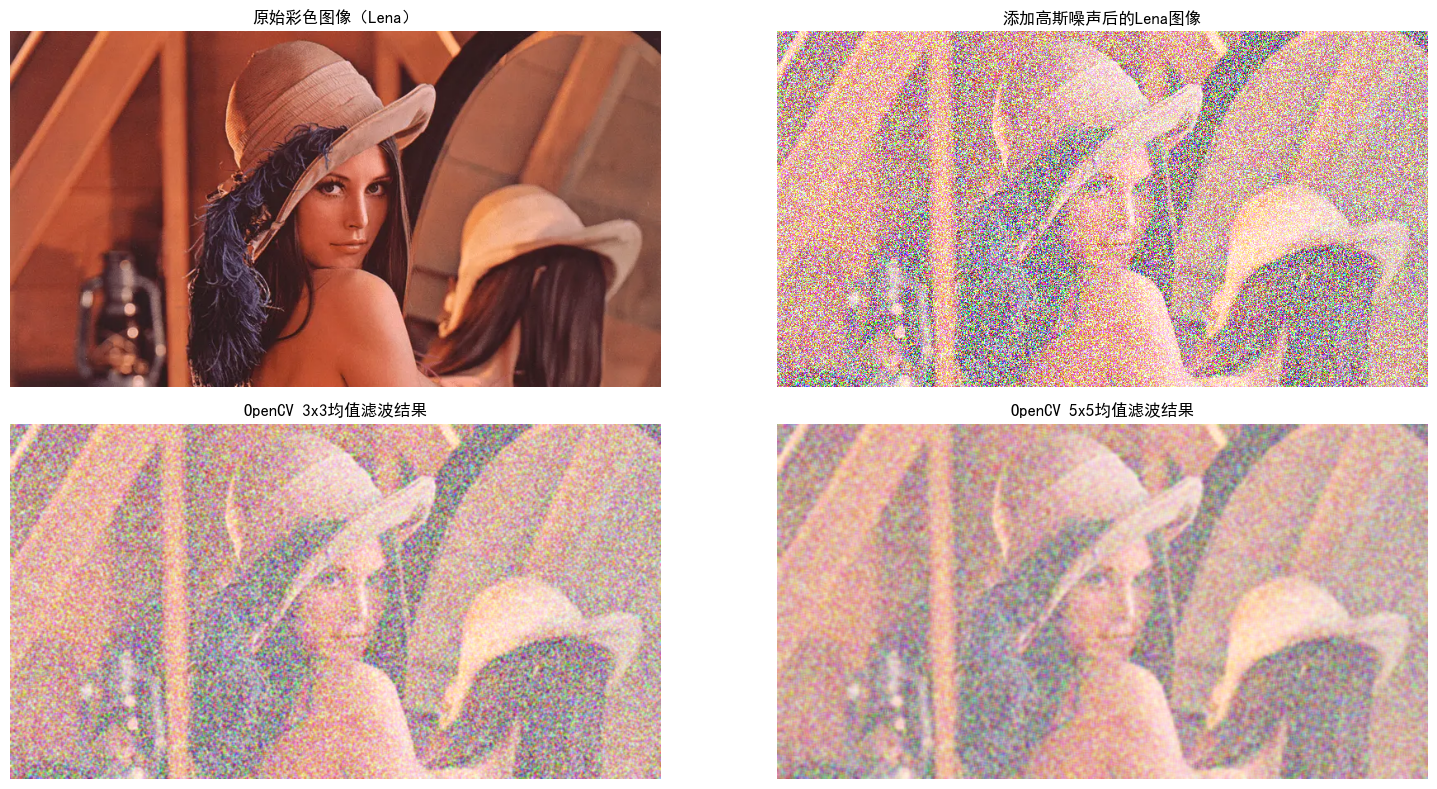

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# -------- 核心：添加Matplotlib中文显示配置 --------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 基于OpenCV实现均值滤波 ----------------------
# 关键修改：图像路径改为 img/lena.jpeg，先读取彩色图
img = cv2.imread("../img/lena.jpeg")
if img is None:
    raise FileNotFoundError("未找到测试图像，请确保：1. img 目录存在；2. lena.jpeg 放在 img 目录下；3. 后缀为 jpeg（非 jpg 需对应修改）")

# 转换为灰度图（可选，也可直接处理彩色图）
img_gray = cv2.imread("../img/lena.jpeg", cv2.IMREAD_GRAYSCALE)
# BGR 转 RGB（适配Matplotlib显示彩色图像）
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 添加高斯噪声
np.random.seed(42)
noise = np.random.normal(0, 20, img.shape).astype(np.uint8)
noisy_img = cv2.add(img, noise)
noisy_img_rgb = cv2.cvtColor(noisy_img, cv2.COLOR_BGR2RGB)

# 执行OpenCV均值滤波
filtered_img_3 = cv2.blur(noisy_img, ksize=(3, 3))
filtered_img_3_rgb = cv2.cvtColor(filtered_img_3, cv2.COLOR_BGR2RGB)

filtered_img_5 = cv2.blur(noisy_img, ksize=(5, 5))
filtered_img_5_rgb = cv2.cvtColor(filtered_img_5, cv2.COLOR_BGR2RGB)

# 可视化（中文标题正常显示）
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("原始彩色图像（Lena）", fontsize=12)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(noisy_img_rgb)
plt.title("添加高斯噪声后的Lena图像", fontsize=12)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(filtered_img_3_rgb)
plt.title("OpenCV 3x3均值滤波结果", fontsize=12)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(filtered_img_5_rgb)
plt.title("OpenCV 5x5均值滤波结果", fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()